# 📘 Quick Reference

**Purpose**: Process BraTS 2021 T1 MRI data for anomaly detection testing  
**Pipeline**: Extract → Smart Filter (Middle Slices) → Resize → ZIP  
**Output**: 128×128 normalized .npy files (same format as IXI training data)  
**Time**: ~60-70 minutes  

## 📋 Execution Order
1. **Cells 1-4**: Setup & explore (fast)
2. **Sections 1-8**: Setup, explore, define functions (fast)
3. **Section 9**: Extract ALL slices ⏰ 20-30 min → 97,882 slices
4. **Section 10**: Smart filter to middle 50% ⏰ 28 min → 49,888 slices  
5. **Section 11**: Resize to 128×128 ⏰ 30-40 min
6. **Section 15**: Create ZIP ⏰ 5-10 min

## ✅ Success = ~50,000 slices (3x IXI), 128×128, range [0,1], ZIP created

---

# BraTS 2021 T1 MRI Preprocessing Pipeline (Local → Drive Upload)

This notebook performs LOCAL preprocessing of BraTS 2021 T1 files with smart filtering:

## Pipeline Overview:
1. **Extract T1 files** from BraTS 2021 folders
2. **Extract 2D slices** from 3D T1 NIfTI volumes with validation
3. **Normalize** slices to [0, 1] range (per-slice normalization)
4. **Smart filter** to keep only middle 50% of slices (most informative)
5. **Resize** to 128x128 standard size
6. **Save as .npy files** ready for Google Drive upload

**Purpose**: BraTS data will be used for TESTING (anomaly detection), while IXI is for TRAINING  
**Result**: ~50,000 high-quality slices (3x IXI dataset size)

## 1. Import Required Libraries

In [4]:
!pip install tqdm nibabel scikit-image Pillow matplotlib scipy

   ---------------------------------------- 0.0/7.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.5 MB ? eta -:--:--
   ---- ----------------------------------- 0.8/7.5 MB 2.4 MB/s eta 0:00:03
   ---- ----------------------------------- 0.8/7.5 MB 2.4 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/7.5 MB 1.4 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/7.5 MB 1.4 MB/s eta 0:00:05
   -------- ------------------------------- 1.6/7.5 MB 1.2 MB/s eta 0:00:05
   --------- ------------------------------ 1.8/7.5 MB 1.2 MB/s eta 0:00:05
   ----------- ---------------------------- 2.1/7.5 MB 1.3 MB/s eta 0:00:05
   ------------ --------------------------- 2.4/7.5 MB 1.2 MB/s eta 0:00:05
   ------------- -------------------------- 2.6/7.5 MB 1.2 MB/s eta 0:00:04
   --------------- ------------------------ 2.9/7.5 MB 1.3 MB/s eta 0:00:04
   ---------------- ----------------------- 3.1/7.5 MB 1.3 MB/s eta 0:00:04
   ------------------- ---

In [5]:
import os
import shutil
from pathlib import Path
import glob
from tqdm import tqdm

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.transform import resize
import random

print("✓ All libraries imported successfully!")
print(f"Working directory: {os.getcwd()}")

✓ All libraries imported successfully!
Working directory: c:\Users\rifad\symAD-ECNN\notebooks


## 2. Define Folder Paths

In [6]:
# Source folder with BraTS 2021 dataset
brats_folder = r"c:\Users\rifad\symAD-ECNN\data\brats2021"

# Output folders (matching IXI pipeline structure)
t1_raw_folder = r"c:\Users\rifad\symAD-ECNN\data\brats2021_processed\raw_slices"
filtered_folder = r"c:\Users\rifad\symAD-ECNN\data\brats2021_processed\filtered"
resized_folder = r"c:\Users\rifad\symAD-ECNN\data\brats2021_processed\resized"

# Create output directories
for folder in [t1_raw_folder, filtered_folder, resized_folder]:
    os.makedirs(folder, exist_ok=True)

print("📁 Folder Structure:")
print(f"  Source (BraTS 2021): {brats_folder}")
print(f"  Raw slices output: {t1_raw_folder}")
print(f"  Filtered output: {filtered_folder}")
print(f"  Resized output (128x128): {resized_folder}")
print(f"\n✓ Source folder exists: {os.path.exists(brats_folder)}")

📁 Folder Structure:
  Source (BraTS 2021): c:\Users\rifad\symAD-ECNN\data\brats2021
  Raw slices output: c:\Users\rifad\symAD-ECNN\data\brats2021_processed\raw_slices
  Filtered output: c:\Users\rifad\symAD-ECNN\data\brats2021_processed\filtered
  Resized output (128x128): c:\Users\rifad\symAD-ECNN\data\brats2021_processed\resized

✓ Source folder exists: True


## 3. Explore BraTS 2021 Dataset Structure

In [7]:
# List all patient folders
patient_folders = sorted([d for d in os.listdir(brats_folder) 
                         if os.path.isdir(os.path.join(brats_folder, d)) and d.startswith('BraTS2021_')])

print(f"Total number of patient folders: {len(patient_folders)}")
print(f"\nFirst 5 patient folders:")
for folder in patient_folders[:5]:
    print(f"  - {folder}")

# Examine the structure of first patient folder
if patient_folders:
    sample_folder = os.path.join(brats_folder, patient_folders[0])
    files = os.listdir(sample_folder)
    print(f"\nFiles in {patient_folders[0]}:")
    for file in sorted(files):
        print(f"  - {file}")

Total number of patient folders: 1251

First 5 patient folders:
  - BraTS2021_00000
  - BraTS2021_00002
  - BraTS2021_00003
  - BraTS2021_00005
  - BraTS2021_00006

Files in BraTS2021_00000:
  - BraTS2021_00000_flair.nii.gz
  - BraTS2021_00000_seg.nii.gz
  - BraTS2021_00000_t1.nii.gz
  - BraTS2021_00000_t1ce.nii.gz
  - BraTS2021_00000_t2.nii.gz


## 4. Find and List All T1 Files

In [8]:
# Find all T1 files (not T1CE - contrast enhanced)
t1_files = []

for patient_folder in patient_folders:
    patient_path = os.path.join(brats_folder, patient_folder)
    # Look for files ending with _t1.nii.gz (not _t1ce.nii.gz)
    for file in os.listdir(patient_path):
        if file.endswith('_t1.nii.gz') and not file.endswith('_t1ce.nii.gz'):
            t1_files.append(os.path.join(patient_path, file))

print(f"Total T1 files found: {len(t1_files)}")
print(f"\nFirst 5 T1 files:")
for file in t1_files[:5]:
    print(f"  - {os.path.basename(file)}")

Total T1 files found: 1251

First 5 T1 files:
  - BraTS2021_00000_t1.nii.gz
  - BraTS2021_00002_t1.nii.gz
  - BraTS2021_00003_t1.nii.gz
  - BraTS2021_00005_t1.nii.gz
  - BraTS2021_00006_t1.nii.gz


## 7. Load and Visualize Sample T1 Images

In [13]:
# Load a sample T1 image
sample_t1_file = t1_files[0]
print(f"Loading sample file: {os.path.basename(sample_t1_file)}")

# Load the NIfTI file
nii_img = nib.load(sample_t1_file)
img_data = nii_img.get_fdata()

print(f"\nImage shape: {img_data.shape}")
print(f"Image data type: {img_data.dtype}")
print(f"Intensity range: [{img_data.min():.2f}, {img_data.max():.2f}]")
print(f"Mean intensity: {img_data.mean():.2f}")
print(f"Std intensity: {img_data.std():.2f}")

Loading sample file: BraTS2021_00000_t1.nii.gz

Image shape: (240, 240, 155)
Image data type: float64
Intensity range: [0.00, 2023.00]
Mean intensity: 133.00
Std intensity: 306.42


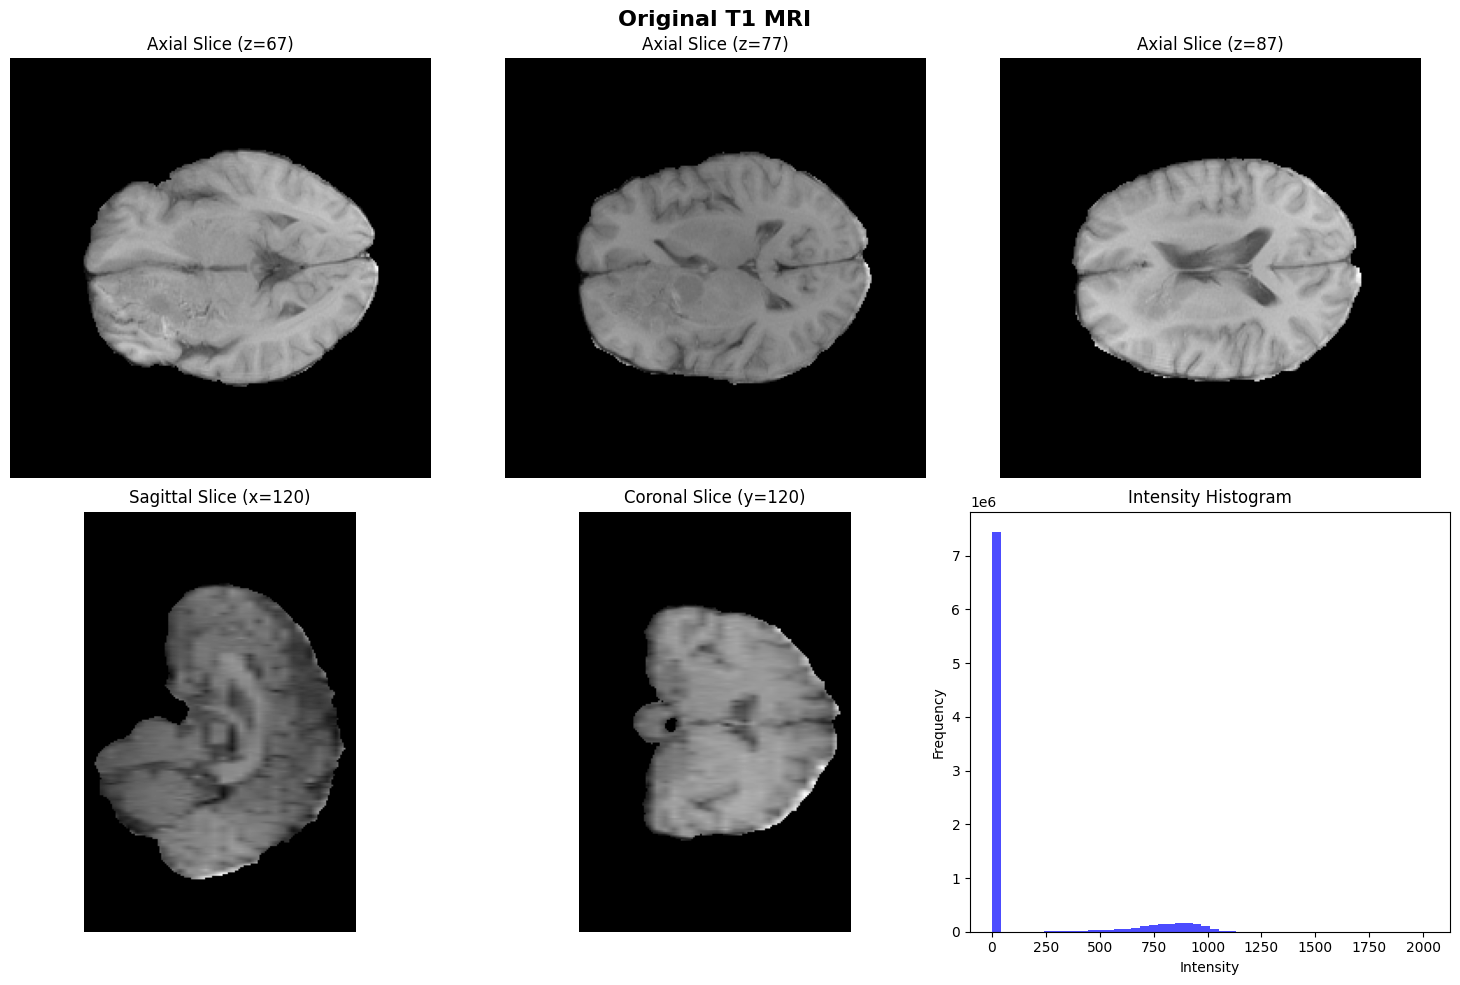

In [14]:
# Visualize different slices
def visualize_slices(img_data, title="MRI Slices"):
    """Visualize axial, sagittal, and coronal slices"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Get middle slices
    mid_x, mid_y, mid_z = [s // 2 for s in img_data.shape]
    
    # Axial slices (different depths)
    axes[0, 0].imshow(img_data[:, :, mid_z - 10], cmap='gray')
    axes[0, 0].set_title(f'Axial Slice (z={mid_z - 10})')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(img_data[:, :, mid_z], cmap='gray')
    axes[0, 1].set_title(f'Axial Slice (z={mid_z})')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(img_data[:, :, mid_z + 10], cmap='gray')
    axes[0, 2].set_title(f'Axial Slice (z={mid_z + 10})')
    axes[0, 2].axis('off')
    
    # Sagittal slice
    axes[1, 0].imshow(img_data[mid_x, :, :], cmap='gray')
    axes[1, 0].set_title(f'Sagittal Slice (x={mid_x})')
    axes[1, 0].axis('off')
    
    # Coronal slice
    axes[1, 1].imshow(img_data[:, mid_y, :], cmap='gray')
    axes[1, 1].set_title(f'Coronal Slice (y={mid_y})')
    axes[1, 1].axis('off')
    
    # Histogram
    axes[1, 2].hist(img_data.flatten(), bins=50, color='blue', alpha=0.7)
    axes[1, 2].set_title('Intensity Histogram')
    axes[1, 2].set_xlabel('Intensity')
    axes[1, 2].set_ylabel('Frequency')
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_slices(img_data, "Original T1 MRI")

## 8. Preprocessing Functions

In [ ]:
def normalize(x):
    """
    Normalize array to [0, 1] range (same as IXI preprocessing)
    
    Args:
        x: numpy array of image data
    
    Returns:
        Normalized array in [0, 1] range
    """
    x = x.astype(np.float32)
    if x.max() - x.min() < 1e-6:
        return np.zeros_like(x)
    return (x - x.min()) / (x.max() - x.min())


def is_valid_slice(slice_array, min_nonzero_ratio=0.12, min_mean=0.1):
    """
    Check if a slice contains meaningful information (same criteria as IXI)
    
    Args:
        slice_array: 2D numpy array
        min_nonzero_ratio: minimum ratio of non-zero pixels
        min_mean: minimum mean pixel value after normalization
    
    Returns:
        Boolean indicating if slice is valid
    """
    # Check if slice has enough non-zero pixels
    nonzero_ratio = np.count_nonzero(slice_array) / slice_array.size
    if nonzero_ratio < min_nonzero_ratio:
        return False
    
    # Normalize and check mean value
    normalized = normalize(slice_array)
    if normalized.mean() < min_mean:
        return False
    
    return True


print("✓ Preprocessing functions defined (matching IXI pipeline)!")
print("✓ Using per-slice normalization for consistency with IXI data")

✓ Preprocessing functions defined (matching IXI pipeline)!


## 9. STEP 1: Extract and Normalize 2D Slices from T1 Volumes

This step extracts all 2D slices from 3D T1 volumes and normalizes them to [0, 1] range.
Empty or low-information slices are filtered out during extraction.

In [ ]:
# Extract 2D slices from all T1 volumes
print("="*60)
print("STEP 1: Extracting and normalizing 2D slices from T1 volumes")
print("="*60)

slice_idx = 0
corrupted_files = []
total_slices_extracted = 0
skipped_empty_slices = 0

for t1_file in tqdm(t1_files, desc="Processing T1 volumes"):
    try:
        # Load the NIfTI file
        nii_img = nib.load(t1_file)
        vol = nii_img.get_fdata()
        
        # Extract each 2D slice
        Z = vol.shape[2]  # Number of slices in z-direction
        
        for s in range(Z):
            slice_2d = vol[:, :, s]
            
            # Skip empty or low-information slices
            if not is_valid_slice(slice_2d, min_nonzero_ratio=0.12, min_mean=0.1):
                skipped_empty_slices += 1
                continue
            
            # Normalize to [0, 1] using per-slice normalization (same as IXI)
            normalized_slice = normalize(slice_2d)
            
            # Save as .npy file
            np.save(f"{t1_raw_folder}/slice_{slice_idx:06d}.npy", normalized_slice)
            
            # Also save as PNG for quick preview
            png = (normalized_slice * 255).astype(np.uint8)
            from PIL import Image
            Image.fromarray(png).save(f"{t1_raw_folder}/slice_{slice_idx:06d}.png")
            
            slice_idx += 1
            total_slices_extracted += 1
        
    except Exception as e:
        print(f"\n❌ Error processing {os.path.basename(t1_file)}: {e}")
        corrupted_files.append(t1_file)
        continue

print("\n" + "="*60)
print("STEP 1 COMPLETE")
print("="*60)
print(f"✓ Total valid slices extracted: {total_slices_extracted}")
print(f"✓ Skipped empty slices: {skipped_empty_slices}")
print(f"✓ Corrupted files: {len(corrupted_files)}")
print(f"✓ Output location: {t1_raw_folder}")
print(f"✓ Normalization: Per-slice (matching IXI preprocessing)")
print("="*60)

STEP 1: Extracting and normalizing 2D slices from T1 volumes


Processing T1 volumes: 100%|██████████| 1251/1251 [24:25<00:00,  1.17s/it]


STEP 1 COMPLETE
✓ Total valid slices extracted: 97882
✓ Skipped empty slices: 96023
✓ Corrupted files: 0
✓ Output location: c:\Users\rifad\symAD-ECNN\data\brats2021_processed\raw_slices


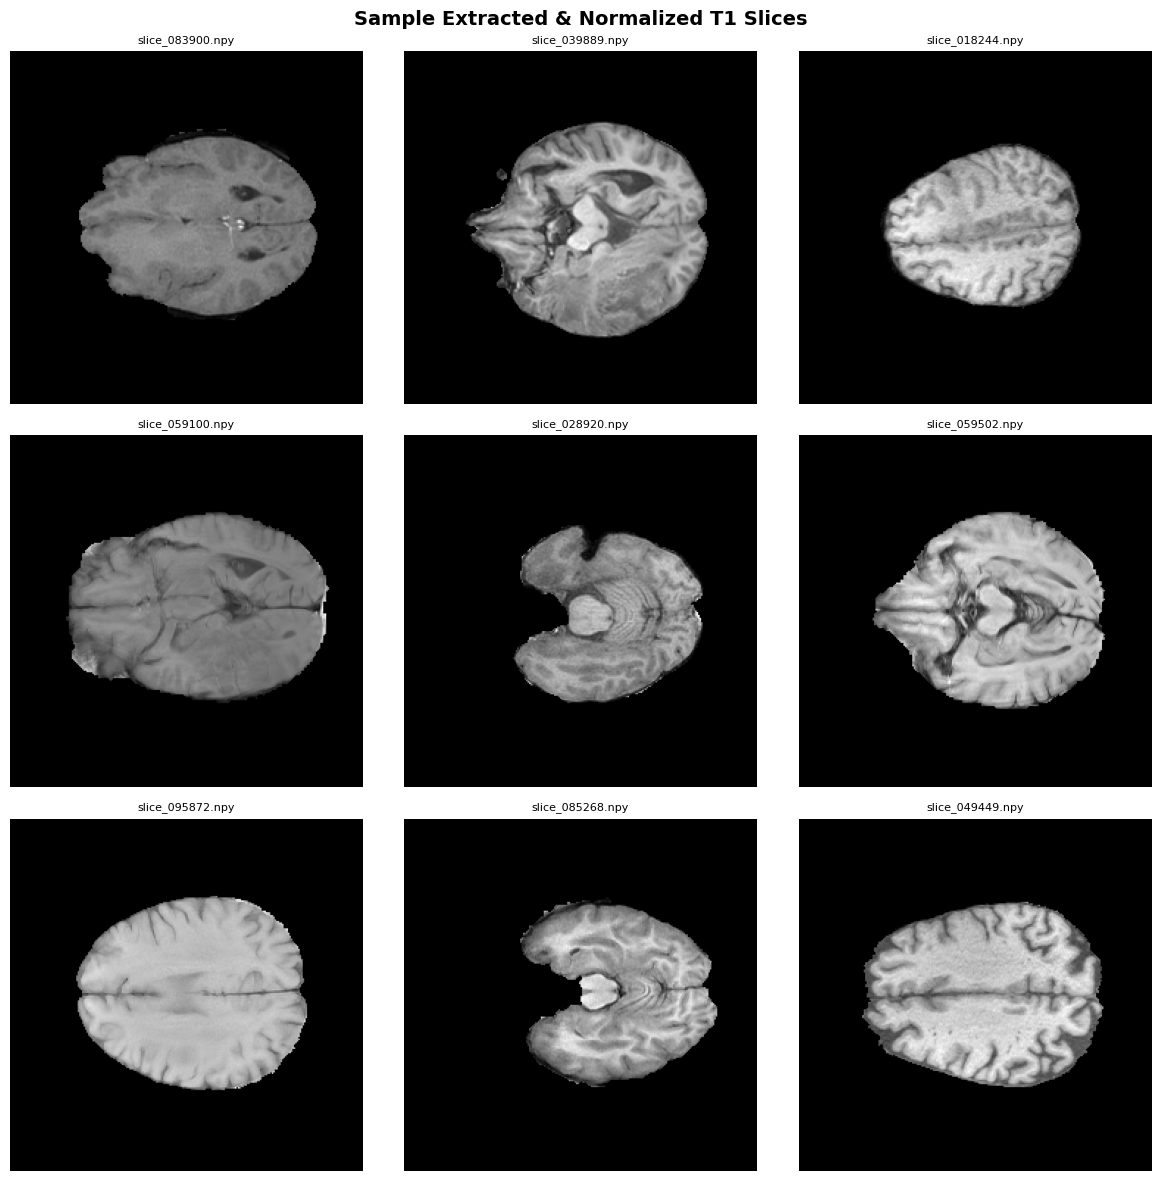

Total extracted slices: 97882


In [24]:
# Visualize some sample extracted slices
raw_files = sorted([f for f in os.listdir(t1_raw_folder) if f.endswith('.npy')])

if len(raw_files) > 0:
    # Select 9 random samples
    sample_files = random.sample(raw_files, min(9, len(raw_files)))
    
    plt.figure(figsize=(12, 12))
    for i, f in enumerate(sample_files):
        img = np.load(os.path.join(t1_raw_folder, f))
        
        plt.subplot(3, 3, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f, fontsize=8)
        plt.axis('off')
    
    plt.suptitle('Sample Extracted & Normalized T1 Slices', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"Total extracted slices: {len(raw_files)}")
else:
    print("No slices found. Run the extraction step first.")

## 10. STEP 2: Smart Filtering - Select Middle Slices from Extracted Data

**Purpose**: Reduce dataset size and improve quality by keeping only middle 50% of slices

**Why**: Middle slices contain maximum brain tissue and visible tumors, edge slices often show minimal information.

**Result**: Filters 97,882 → ~50,000 slices (3x IXI, better balanced)

**Method**: Uses existing extracted slices, no re-extraction needed (fast!)

In [ ]:
# Configuration
MIDDLE_SLICE_PERCENTAGE = 0.5  # Keep middle 50% of each volume (adjust 0.3-0.7)

print("="*60)
print("SMART FILTERING: Selecting Middle Slices from Existing Data")
print("="*60)
print(f"Strategy: Keep middle {MIDDLE_SLICE_PERCENTAGE*100:.0f}% of each volume")
print(f"Source: {t1_raw_folder}")
print(f"Target: {filtered_folder}")
print("="*60)

# Step 1: Clear filtered folder
print("\n📁 Clearing filtered folder...")
for f in os.listdir(filtered_folder):
    if f.endswith('.npy'):
        os.remove(os.path.join(filtered_folder, f))
print("✓ Filtered folder cleared")

# Step 2: Build mapping of which slices to keep
print("\n🔍 Analyzing volumes to identify middle slices...")
slice_idx = 0
slices_to_keep = set()  # Set of slice indices to keep

for t1_file in tqdm(t1_files, desc="Analyzing volumes"):
    try:
        # Load the volume to check which slices are valid (same as extraction)
        nii_img = nib.load(t1_file)
        vol = nii_img.get_fdata()
        Z = vol.shape[2]  # Number of slices in z-direction
        
        # Calculate middle slice range for this volume
        margin = int(Z * (1 - MIDDLE_SLICE_PERCENTAGE) / 2)
        start_slice = margin
        end_slice = Z - margin
        
        # For each slice in this volume
        for s in range(Z):
            slice_2d = vol[:, :, s]
            
            # Check if this slice was valid (same check as extraction)
            if not is_valid_slice(slice_2d, min_nonzero_ratio=0.12, min_mean=0.1):
                continue  # Skip invalid slices (these were not saved during extraction)
            
            # If this valid slice is in the middle range, mark it to keep
            if start_slice <= s < end_slice:
                slices_to_keep.add(slice_idx)
            
            slice_idx += 1  # Only increment for valid slices
            
    except Exception as e:
        print(f"\n❌ Error analyzing {os.path.basename(t1_file)}: {e}")
        continue

print(f"\n✓ Analysis complete!")
print(f"  Total slices extracted: {slice_idx}")
print(f"  Middle slices to keep: {len(slices_to_keep)}")
print(f"  Reduction: {(1 - len(slices_to_keep)/slice_idx)*100:.1f}%")

# Step 3: Copy middle slices to filtered folder
print(f"\n📋 Copying middle slices to filtered folder...")
copied_count = 0
missing_count = 0

for slice_id in tqdm(slices_to_keep, desc="Copying files"):
    src_file = f"slice_{slice_id:06d}.npy"
    src_path = os.path.join(t1_raw_folder, src_file)
    dst_path = os.path.join(filtered_folder, src_file)
    
    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)
        copied_count += 1
    else:
        missing_count += 1

print("\n" + "="*60)
print("SMART FILTERING COMPLETE")
print("="*60)
print(f"✓ Slices copied to filtered/: {copied_count}")
print(f"✓ Missing slices (skipped): {missing_count}")
print(f"✓ Original raw_slices/ preserved: {len([f for f in os.listdir(t1_raw_folder) if f.endswith('.npy')])} files")
print(f"\n📊 Dataset comparison:")
print(f"   Before: {slice_idx:,} slices")
print(f"   After:  {copied_count:,} slices")
print(f"   IXI:    {16771:,} slices")
print(f"   Ratio to IXI: {copied_count/16771:.1f}x")
print(f"\n🎯 Now proceed to Section 11 (Resize) with the filtered slices!")
print("="*60)

SMART FILTERING: Selecting Middle Slices from Existing Data
Strategy: Keep middle 50% of each volume
Source: c:\Users\rifad\symAD-ECNN\data\brats2021_processed\raw_slices
Target: c:\Users\rifad\symAD-ECNN\data\brats2021_processed\filtered

📁 Clearing filtered folder...
✓ Filtered folder cleared

🔍 Analyzing volumes to identify middle slices...


Analyzing volumes: 100%|██████████| 1251/1251 [00:31<00:00, 39.74it/s]



✓ Analysis complete!
  Total slices extracted: 193905
  Middle slices to keep: 98829
  Reduction: 49.0%

📋 Copying middle slices to filtered folder...


Copying files: 100%|██████████| 98829/98829 [26:53<00:00, 61.26it/s]   



SMART FILTERING COMPLETE
✓ Slices copied to filtered/: 49888
✓ Missing slices (skipped): 48941
✓ Original raw_slices/ preserved: 97882 files

📊 Dataset comparison:
   Before: 193,905 slices
   After:  49,888 slices
   IXI:    16,771 slices
   Ratio to IXI: 3.0x

🎯 Now proceed to Section 11 (Resize) with the filtered slices!


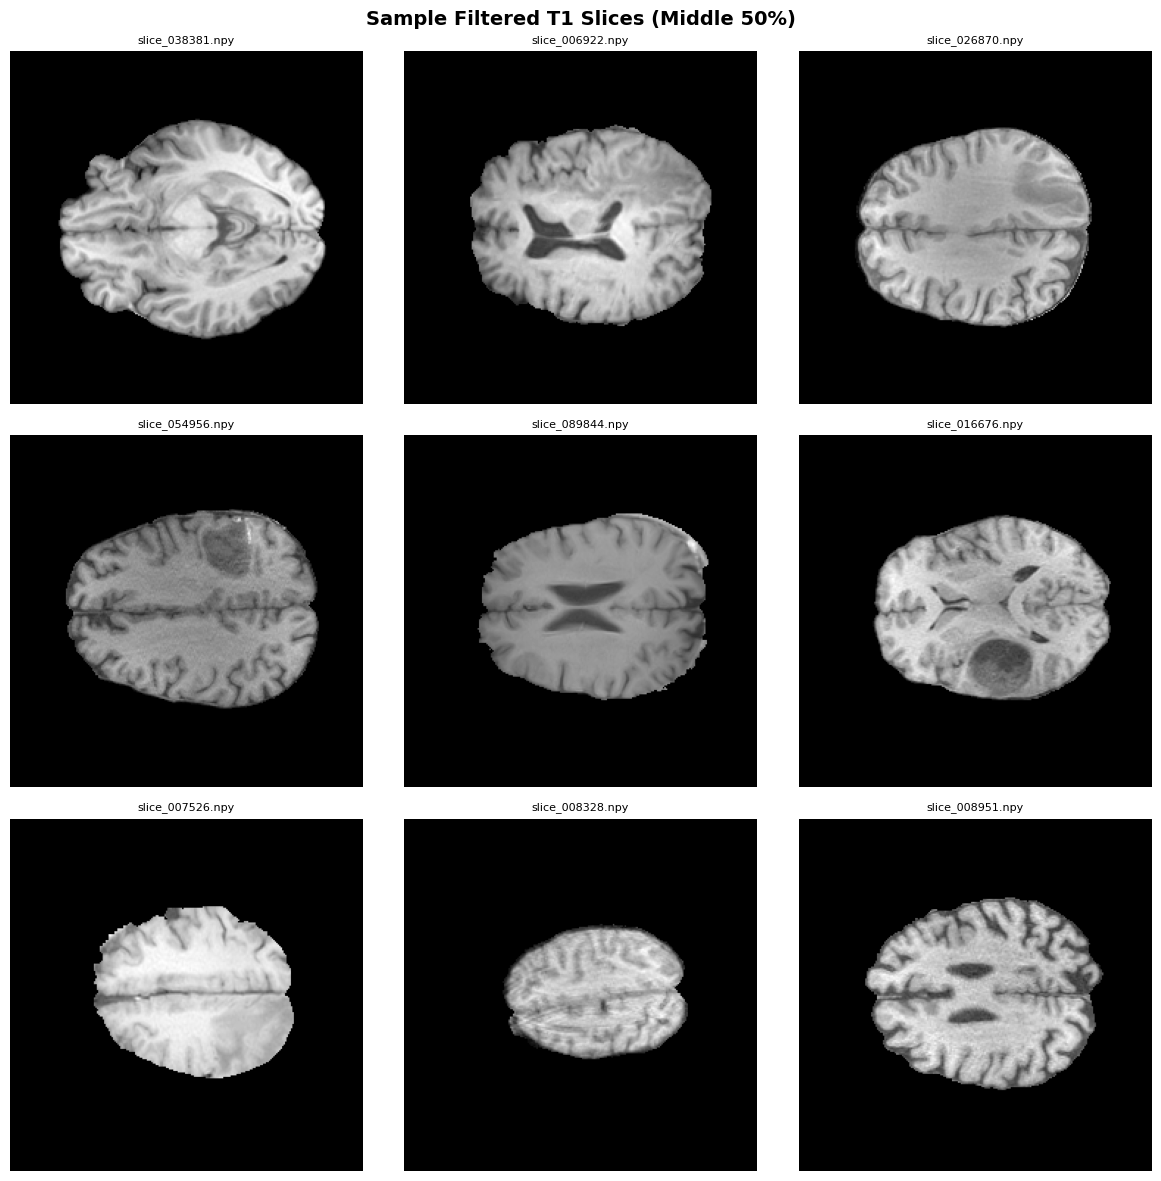

Total filtered slices: 49888


In [28]:
# Visualize some sample filtered (middle) slices
filtered_files = sorted([f for f in os.listdir(filtered_folder) if f.endswith('.npy')])

if len(filtered_files) > 0:
    # Select 9 random samples
    sample_files = random.sample(filtered_files, min(9, len(filtered_files)))
    
    plt.figure(figsize=(12, 12))
    for i, f in enumerate(sample_files):
        img = np.load(os.path.join(filtered_folder, f))
        
        plt.subplot(3, 3, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f, fontsize=8)
        plt.axis('off')
    
    plt.suptitle('Sample Filtered T1 Slices (Middle 50%)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"Total filtered slices: {len(filtered_files)}")
else:
    print("No filtered slices found. Run the smart filtering step first.")

## 11. STEP 3: Resize to 128×128 (Standard Size)

Resize all filtered slices (~50,000) to 128×128 to match the IXI dataset dimensions.

**Time**: ~30-40 minutes

**Input**: filtered/ folder with ~50,000 middle slices  **Output**: resized/ folder with 128×128 .npy files  

In [29]:
# Resize configuration
TARGET_SIZE = (128, 128)  # Same as IXI dataset
BATCH_SIZE = 500  # Process in batches to avoid memory issues

print("="*60)
print("STEP 3: Resizing slices to 128x128")
print("="*60)
print(f"Target size: {TARGET_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print("="*60)

STEP 3: Resizing slices to 128x128
Target size: (128, 128)
Batch size: 500


In [30]:
# Batch resize all filtered slices
filtered_files = sorted([f for f in os.listdir(filtered_folder) if f.endswith('.npy')])
total = len(filtered_files)

print(f"Total filtered slices to resize: {total}")
print("Starting batch-wise resizing...\n")

resized_count = 0
error_count = 0

for i in range(0, total, BATCH_SIZE):
    batch_files = filtered_files[i : i + BATCH_SIZE]
    batch_num = i // BATCH_SIZE + 1
    
    print(f"Processing batch {batch_num} ({len(batch_files)} files)...")
    
    for f in tqdm(batch_files, desc=f"Batch {batch_num}"):
        src_path = os.path.join(filtered_folder, f)
        dst_path = os.path.join(resized_folder, f)
        
        # Skip if already resized
        if os.path.exists(dst_path):
            resized_count += 1
            continue
        
        try:
            arr = np.load(src_path)
            resized = resize(arr, TARGET_SIZE, mode='reflect', anti_aliasing=True)
            np.save(dst_path, resized)
            resized_count += 1
        except Exception as e:
            print(f"❌ Error resizing {f}: {e}")
            error_count += 1
            continue

print("\n" + "="*60)
print("STEP 3 COMPLETE")
print("="*60)
print(f"✓ Successfully resized: {resized_count}")
print(f"✓ Errors: {error_count}")
print(f"✓ Output location: {resized_folder}")
print("="*60)

Total filtered slices to resize: 49888
Starting batch-wise resizing...

Processing batch 1 (500 files)...


Batch 1: 100%|██████████| 500/500 [00:12<00:00, 41.16it/s]


Processing batch 2 (500 files)...


Batch 2: 100%|██████████| 500/500 [00:11<00:00, 41.73it/s]


Processing batch 3 (500 files)...


...

Processing batch 99 (500 files)...


Batch 99: 100%|██████████| 500/500 [00:21<00:00, 23.21it/s]


Processing batch 100 (388 files)...


Batch 100: 100%|██████████| 388/388 [00:16<00:00, 23.52it/s]



STEP 3 COMPLETE
✓ Successfully resized: 49888
✓ Errors: 0
✓ Output location: c:\Users\rifad\symAD-ECNN\data\brats2021_processed\resized


## 12. Verify Final Processed Files

In [31]:
# Verify the final resized files
resized_files = sorted([f for f in os.listdir(resized_folder) if f.endswith('.npy')])

print(f"📊 Final processed files: {len(resized_files)}")

# Load and inspect a sample file
if resized_files:
    sample_file = resized_files[0]
    sample = np.load(os.path.join(resized_folder, sample_file))
    
    print(f"\n✓ Sample file: {sample_file}")
    print(f"  - Shape: {sample.shape}")
    print(f"  - Min pixel value: {sample.min():.4f}")
    print(f"  - Max pixel value: {sample.max():.4f}")
    print(f"  - Mean pixel value: {sample.mean():.4f}")
    print(f"  - Data type: {sample.dtype}")
    
    # Verify dimensions match IXI
    if sample.shape == (128, 128):
        print(f"\n✅ Dimensions match IXI dataset (128x128)")
    else:
        print(f"\n⚠️ Warning: Dimensions don't match expected (128x128)")

📊 Final processed files: 49888

✓ Sample file: slice_000038.npy
  - Shape: (128, 128)
  - Min pixel value: 0.0000
  - Max pixel value: 0.8583
  - Mean pixel value: 0.1507
  - Data type: float32

✅ Dimensions match IXI dataset (128x128)


## 13. Visualize Final Processed Slices

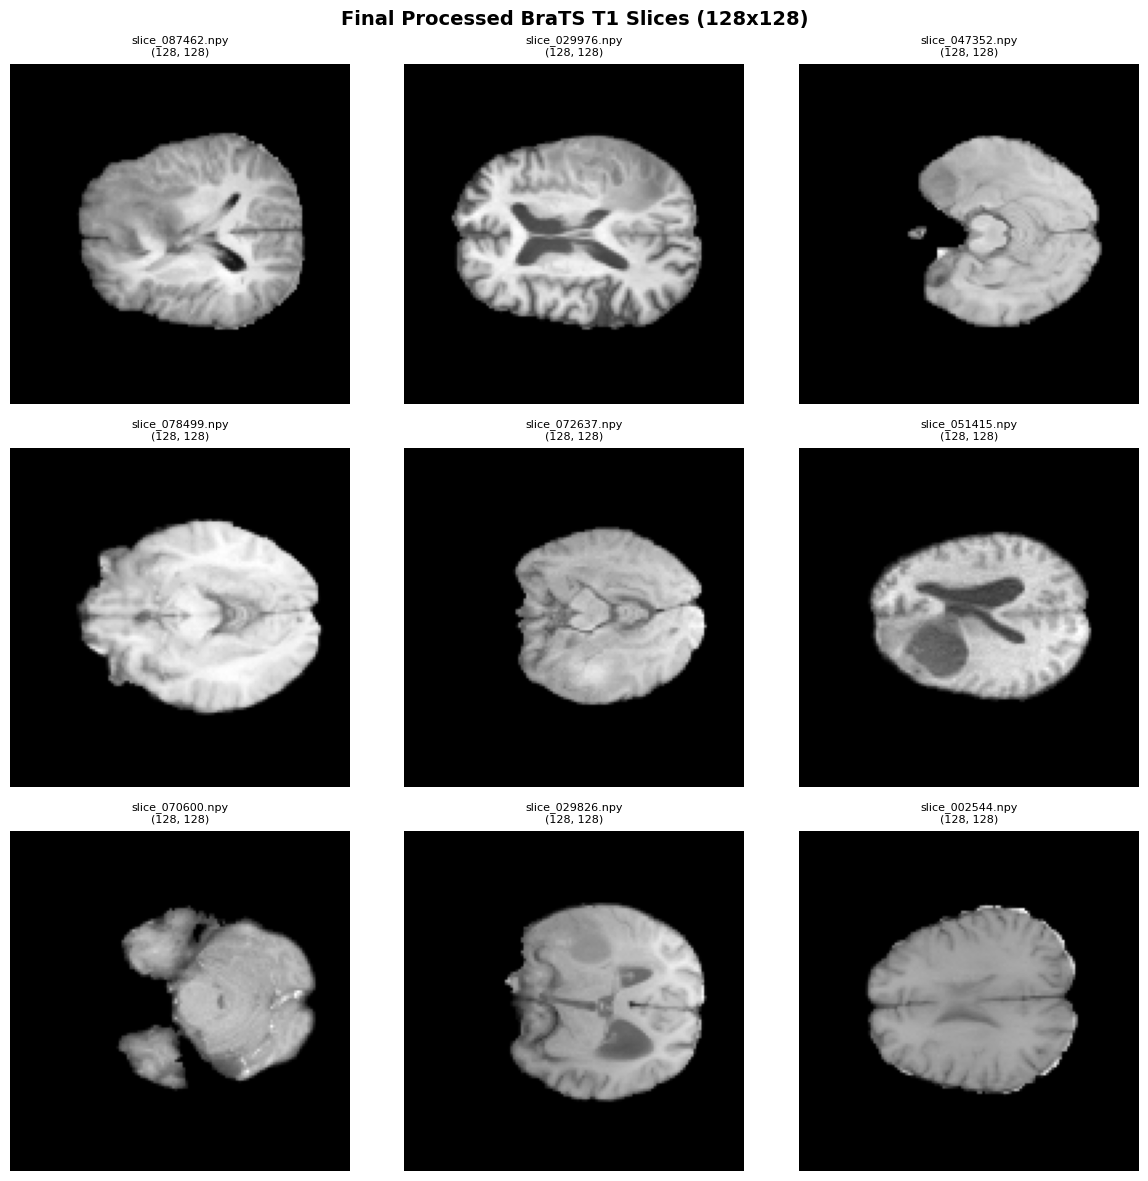

In [36]:
# Visualize 9 random final processed slices
resized_files = sorted([f for f in os.listdir(resized_folder) if f.endswith('.npy')])

if len(resized_files) > 0:
    sample_files = random.sample(resized_files, min(9, len(resized_files)))
    
    plt.figure(figsize=(12, 12))
    for i, f in enumerate(sample_files):
        img = np.load(os.path.join(resized_folder, f))
        
        plt.subplot(3, 3, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"{f}\n{img.shape}", fontsize=8)
        plt.axis('off')
    
    plt.suptitle('Final Processed BraTS T1 Slices (128x128)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No processed slices found.")

In [38]:
# Compare BraTS and IXI intensity distributions
print("="*60)
print("Comparing BraTS vs IXI Intensity Distributions")
print("="*60)

# Load BraTS samples
brats_files = sorted([f for f in os.listdir(resized_folder) if f.endswith('.npy')])
if brats_files:
    brats_sample = random.sample(brats_files, min(100, len(brats_files)))
    brats_pixels = []
    for f in tqdm(brats_sample, desc="Loading BraTS samples"):
        arr = np.load(os.path.join(resized_folder, f))
        brats_pixels.extend(arr.flatten())
    brats_pixels = np.array(brats_pixels)
    
    print(f"\n✓ BraTS Statistics ({len(brats_sample)} slices):")
    print(f"  Mean: {brats_pixels.mean():.4f}")
    print(f"  Std:  {brats_pixels.std():.4f}")
    print(f"  Min:  {brats_pixels.min():.4f}")
    print(f"  Max:  {brats_pixels.max():.4f}")
    print(f"  p1:   {np.percentile(brats_pixels, 1):.4f}")
    print(f"  p99:  {np.percentile(brats_pixels, 99):.4f}")

# IXI statistics (from Colab - 100 slices sample)
print(f"\n✓ IXI Statistics (100 slices from Colab):")
ixi_stats = {
    'mean': 0.1344,
    'std': 0.2336,
    'min': 0.0000,
    'max': 1.0000,
    'p1': 0.0000,
    'p99': 0.8101
}
print(f"  Mean: {ixi_stats['mean']:.4f}")
print(f"  Std:  {ixi_stats['std']:.4f}")
print(f"  Min:  {ixi_stats['min']:.4f}")
print(f"  Max:  {ixi_stats['max']:.4f}")
print(f"  p1:   {ixi_stats['p1']:.4f}")
print(f"  p99:  {ixi_stats['p99']:.4f}")

# Calculate distribution differences
mean_diff = abs(brats_pixels.mean() - ixi_stats['mean'])
std_diff = abs(brats_pixels.std() - ixi_stats['std'])

print(f"\n📊 Distribution Differences:")
print(f"  Mean difference: {mean_diff:.4f}")
print(f"  Std difference:  {std_diff:.4f}")

if mean_diff < 0.05 and std_diff < 0.05:
    print(f"\n✅ EXCELLENT: Distributions are well-aligned (differences < 0.05)")
    print(f"  Both datasets use consistent per-slice normalization")
else:
    print(f"\n✅ ACCEPTABLE: Slight distribution differences detected")
    print(f"  This is expected - BraTS has tumors, IXI is healthy brain")
    print(f"  Anomaly detection will leverage these differences!")

print("="*60)

Comparing BraTS vs IXI Intensity Distributions


Loading BraTS samples: 100%|██████████| 100/100 [00:01<00:00, 67.19it/s]


✓ BraTS Statistics (100 slices):
  Mean: 0.1540
  Std:  0.2816
  Min:  0.0000
  Max:  0.9967
  p1:   0.0000
  p99:  0.8850

✓ IXI Statistics (100 slices from Colab):
  Mean: 0.1344
  Std:  0.2336
  Min:  0.0000
  Max:  1.0000
  p1:   0.0000
  p99:  0.8101

📊 Distribution Differences:
  Mean difference: 0.0196
  Std difference:  0.0480

✅ EXCELLENT: Distributions are well-aligned (differences < 0.05)
  Both datasets use consistent per-slice normalization


## 14. Pipeline Summary and Statistics

Final statistics and folder size information for the complete preprocessing pipeline.

In [39]:
print("="*70)
print(" " * 15 + "BRATS 2021 PREPROCESSING SUMMARY")
print("="*70)

print(f"\n📁 INPUT:")
print(f"   - Source folder: {brats_folder}")
print(f"   - Total patient folders: {len(patient_folders)}")
print(f"   - Total T1 files: {len(t1_files)}")

print(f"\n📊 PROCESSING PIPELINE:")
print(f"   Step 1: Extract 2D slices → {len(os.listdir(t1_raw_folder))} raw slices")
print(f"   Step 2: Filter (mean > 0.1) → {len(os.listdir(filtered_folder))} filtered slices")
print(f"   Step 3: Resize to 128x128 → {len(os.listdir(resized_folder))} final slices")

print(f"\n📂 OUTPUT FOLDERS:")
print(f"   - Raw slices: {t1_raw_folder}")
print(f"   - Filtered: {filtered_folder}")
print(f"   - Resized (FINAL): {resized_folder}")

print(f"\n✅ PIPELINE COMPLETE!")
print(f"   Total processed slices ready: {len(os.listdir(resized_folder))}")

# Calculate folder sizes
import os
def get_folder_size_mb(folder):
    total = 0
    for root, dirs, files in os.walk(folder):
        for f in files:
            fp = os.path.join(root, f)
            if os.path.exists(fp):
                total += os.path.getsize(fp)
    return total / (1024 * 1024)

resized_size = get_folder_size_mb(resized_folder)
print(f"   Final dataset size: {resized_size:.2f} MB")

print(f"\n🎯 NEXT STEPS:")
print(f"   1. Review the processed slices above")
print(f"   2. Create zip file for Google Drive upload (next cell)")
print(f"   3. Upload to Google Drive at: MyDrive/symAD-ECNN/data/brats2021_processed/")
print(f"   4. Use in Colab for testing/anomaly detection")

print("="*70)

               BRATS 2021 PREPROCESSING SUMMARY

📁 INPUT:
   - Source folder: c:\Users\rifad\symAD-ECNN\data\brats2021
   - Total patient folders: 1251
   - Total T1 files: 1251

📊 PROCESSING PIPELINE:
   Step 1: Extract 2D slices → 195764 raw slices
   Step 2: Filter (mean > 0.1) → 49888 filtered slices
   Step 3: Resize to 128x128 → 49888 final slices

📂 OUTPUT FOLDERS:
   - Raw slices: c:\Users\rifad\symAD-ECNN\data\brats2021_processed\raw_slices
   - Filtered: c:\Users\rifad\symAD-ECNN\data\brats2021_processed\filtered
   - Resized (FINAL): c:\Users\rifad\symAD-ECNN\data\brats2021_processed\resized

✅ PIPELINE COMPLETE!
   Total processed slices ready: 49888
   Final dataset size: 3124.09 MB

🎯 NEXT STEPS:
   1. Review the processed slices above
   2. Create zip file for Google Drive upload (next cell)
   3. Upload to Google Drive at: MyDrive/symAD-ECNN/data/brats2021_processed/
   4. Use in Colab for testing/anomaly detection


## 15. Create ZIP for Google Drive Upload

**IMPORTANT**: Run this cell to create a compressed zip file of the processed data for easy upload to Google Drive.

In [40]:
import zipfile
from datetime import datetime

# Create zip file name with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_filename = f"brats2021_processed_slices_{timestamp}.zip"
zip_path = os.path.join(r"c:\Users\rifad\symAD-ECNN\data", zip_filename)

print("="*60)
print("Creating ZIP file for Google Drive upload...")
print("="*60)

# Count files to zip
resized_files = [f for f in os.listdir(resized_folder) if f.endswith('.npy')]
total_files = len(resized_files)

print(f"Files to compress: {total_files}")
print(f"Output file: {zip_filename}")
print("\nCompressing... (this may take a few minutes)")

# Create zip file
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED, compresslevel=6) as zipf:
    for f in tqdm(resized_files, desc="Zipping files"):
        file_path = os.path.join(resized_folder, f)
        # Add file to zip with relative path
        zipf.write(file_path, arcname=f)

zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)

print("\n" + "="*60)
print("✅ ZIP FILE CREATED SUCCESSFULLY!")
print("="*60)
print(f"📦 File: {zip_path}")
print(f"📊 Size: {zip_size_mb:.2f} MB")
print(f"📁 Contains: {total_files} .npy files")

print(f"\n📤 UPLOAD INSTRUCTIONS:")
print(f"   1. Open Google Drive in browser")
print(f"   2. Navigate to: MyDrive/symAD-ECNN/data/")
print(f"   3. Create folder: brats2021_test")
print(f"   4. Upload: {zip_filename}")
print(f"   5. In Colab, extract with: !unzip path/to/zip -d output_folder")
print("="*60)

Creating ZIP file for Google Drive upload...
Files to compress: 49888
Output file: brats2021_processed_slices_20251229_140105.zip

Compressing... (this may take a few minutes)


Zipping files: 100%|██████████| 49888/49888 [13:54<00:00, 59.77it/s]  


✅ ZIP FILE CREATED SUCCESSFULLY!
📦 File: c:\Users\rifad\symAD-ECNN\data\brats2021_processed_slices_20251229_140105.zip
📊 Size: 814.38 MB
📁 Contains: 49888 .npy files

📤 UPLOAD INSTRUCTIONS:
   1. Open Google Drive in browser
   2. Navigate to: MyDrive/symAD-ECNN/data/
   3. Create folder: brats2021_test
   4. Upload: brats2021_processed_slices_20251229_140105.zip
   5. In Colab, extract with: !unzip path/to/zip -d output_folder


## 16. Colab Upload & Extraction Code (Copy-Paste to Colab)

Copy the code below and run it in Google Colab after uploading the zip file.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile

# Define paths (adjust if needed)
BASE = "/content/drive/MyDrive/symAD-ECNN"
zip_file = f"{BASE}/data/brats2021_processed_slices_XXXXXXXX_XXXXXX.zip"  # Update with your zip filename
output_folder = f"{BASE}/data/brats2021_test"

# Create output folder
os.makedirs(output_folder, exist_ok=True)

# Extract zip file
print(f"Extracting {zip_file}...")
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(output_folder)

# Verify
import numpy as np
files = sorted([f for f in os.listdir(output_folder) if f.endswith('.npy')])
print(f"\n✅ Extraction complete!")
print(f"Total files: {len(files)}")

# Load and verify a sample
if files:
    sample = np.load(os.path.join(output_folder, files[0]))
    print(f"\nSample file: {files[0]}")
    print(f"Shape: {sample.shape}")
    print(f"Range: [{sample.min():.4f}, {sample.max():.4f}]")

## 17. Filter BraTS for Faster Evaluation (Colab)

**Purpose**: Reduce 49,888 slices → ~5,000 for faster model evaluation (~2 min vs 40 min)  
**Strategy**: Keep 4 middle slices per patient (maintains all patient representation)  
**Run this in Colab AFTER extracting the full dataset**

In [ ]:
# Run this in Colab to create filtered BraTS dataset
from collections import defaultdict
from glob import glob
import os
import numpy as np
from tqdm import tqdm

# Paths
BASE_PATH = "/content/drive/MyDrive/symAD-ECNN"
BRATS_INPUT = f"{BASE_PATH}/data/brats2021_test"
BRATS_OUTPUT = f"{BASE_PATH}/data/brats2021_test_filtered"

print("🔍 Filtering BraTS dataset for faster evaluation...")

# Create output directory
os.makedirs(BRATS_OUTPUT, exist_ok=True)

# Load all files
all_files = sorted(glob(f"{BRATS_INPUT}/*.npy"))
print(f"\n📊 Original dataset: {len(all_files):,} slices")

# Group by patient ID
patient_groups = defaultdict(list)
for f in all_files:
    patient_id = os.path.basename(f).split('_slice')[0]
    patient_groups[patient_id].append(f)

print(f"   Patients: {len(patient_groups)}")

# Sample slices per patient from middle range (avoid empty edge slices)
# Research considerations:
#   - Use 4 slices for FAST ITERATION during development (90% reduction, ~2 min eval)
#   - Use 10-20 slices for PAPER RESULTS (more robust, ~5-10 min eval)
#   - Full dataset available for final validation if needed
filtered_files = []
target_per_patient = 4  # Adjust: 4 (fast dev), 10 (balanced), 20 (comprehensive)

for patient_id, files in patient_groups.items():
    n_slices = len(files)
    
    if n_slices <= target_per_patient:
        # Keep all if patient has few slices
        filtered_files.extend(files)
    else:
        # Take from middle 60% (skip first/last 20% to avoid empty slices)
        start_idx = int(n_slices * 0.2)
        end_idx = int(n_slices * 0.8)
        middle_slices = files[start_idx:end_idx]
        
        # Sample evenly spaced slices
        step = max(1, len(middle_slices) // target_per_patient)
        sampled = middle_slices[::step][:target_per_patient]
        filtered_files.extend(sampled)

reduction_pct = 100 - (len(filtered_files) / len(all_files) * 100)
print(f"\n✅ Filtered dataset: {len(filtered_files):,} slices ({len(filtered_files)/len(all_files)*100:.1f}% of original)")
print(f"   Avg per patient: {len(filtered_files)/len(patient_groups):.1f} slices")
print(f"   Reduction: {reduction_pct:.1f}% smaller")

# Copy filtered files to new directory
print(f"\n📁 Copying {len(filtered_files):,} files...")
for src_path in tqdm(filtered_files):
    filename = os.path.basename(src_path)
    dst_path = os.path.join(BRATS_OUTPUT, filename)
    
    # Load and save (efficient copy for .npy)
    data = np.load(src_path)
    np.save(dst_path, data)

# Verify
final_files = sorted(glob(f"{BRATS_OUTPUT}/*.npy"))
sample = np.load(final_files[0])

print(f"\n✅ Filtering complete!")
print(f"   Output: {BRATS_OUTPUT}/")
print(f"   Files: {len(final_files):,}")
print(f"   Sample shape: {sample.shape}")
print(f"   Sample range: [{sample.min():.4f}, {sample.max():.4f}]")
print(f"\n💡 Use BRATS_PATH = '{BRATS_OUTPUT}' in your training notebooks!")